In [1]:
import numpy as np 
import pandas as pd 
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('dataset\creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [4]:
df.isnull().sum().max()

0

In [5]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
num_legit = df['Class'].value_counts()[0]
num_fraud = df['Class'].value_counts()[1]

print("legits:", num_legit)
print("fraud:", num_fraud)

legits: 284315
fraud: 492


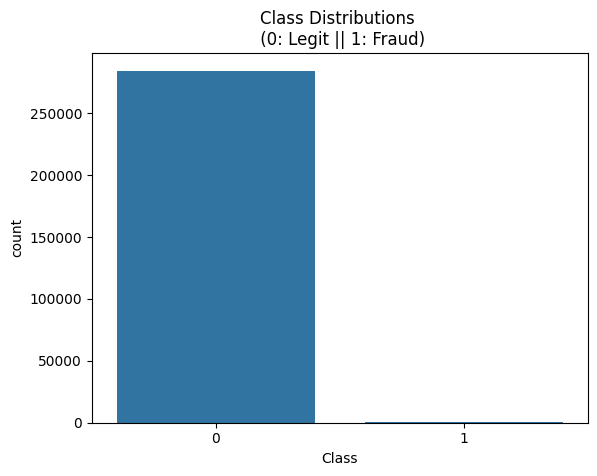

In [9]:
sns.countplot(x='Class', data=df)
plt.title('Class Distributions \n (0: Legit || 1: Fraud)')
plt.show()

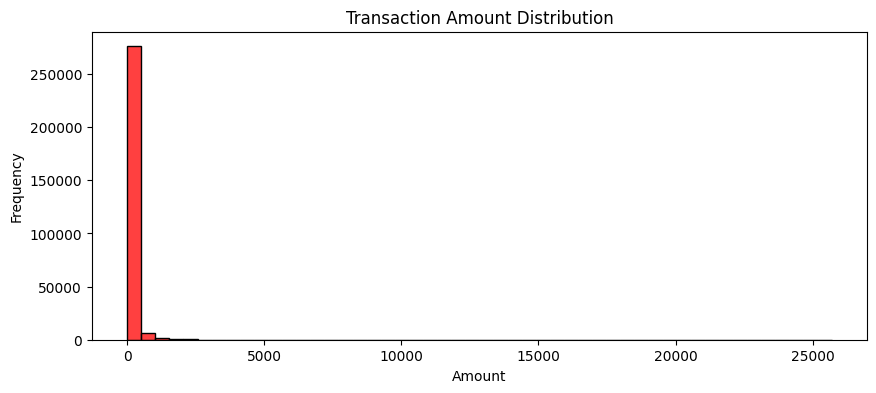

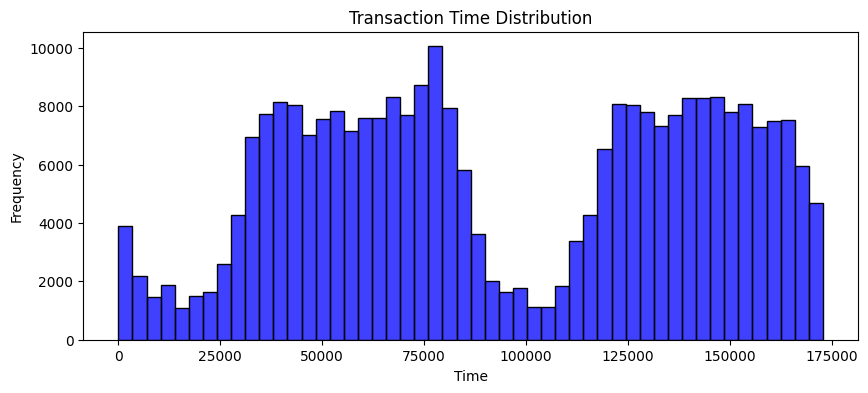

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.histplot(df['Amount'], bins=50, color='red')
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(df['Time'], bins=50, color='blue')
plt.title('Transaction Time Distribution')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

In [ ]:
scaled_check = df.drop(columns=['Class']).agg(['min', 'max']).T
print(scaled_check)

               min            max
Time      0.000000  172792.000000
V1      -56.407510       2.454930
V2      -72.715728      22.057729
V3      -48.325589       9.382558
V4       -5.683171      16.875344
V5     -113.743307      34.801666
V6      -26.160506      73.301626
V7      -43.557242     120.589494
V8      -73.216718      20.007208
V9      -13.434066      15.594995
V10     -24.588262      23.745136
V11      -4.797473      12.018913
V12     -18.683715       7.848392
V13      -5.791881       7.126883
V14     -19.214325      10.526766
V15      -4.498945       8.877742
V16     -14.129855      17.315112
V17     -25.162799       9.253526
V18      -9.498746       5.041069
V19      -7.213527       5.591971
V20     -54.497720      39.420904
V21     -34.830382      27.202839
V22     -10.933144      10.503090
V23     -44.807735      22.528412
V24      -2.836627       4.584549
V25     -10.295397       7.519589
V26      -2.604551       3.517346
V27     -22.565679      31.612198
V28     -15.43

In [13]:
import numpy as np

not_scaled = []

for col in df.columns:
    if col not in ['Class']:
        min_val = df[col].min()
        max_val = df[col].max()
        if max_val > 125 or min_val < -120:
            not_scaled.append(col)

print("not scaled:", not_scaled)


not scaled: ['Time', 'Amount']


In [14]:
from sklearn.preprocessing import RobustScaler
robust_scaler = RobustScaler()
df['scaled_amount'] = robust_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = robust_scaler.fit_transform(df['Time'].values.reshape(-1,1))
df.drop(['Time','Amount'], axis=1, inplace=True)

In [15]:
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)
df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

print("legits:", num_legit)
print("fraud:", num_fraud)

X = df.drop('Class', axis=1)
y = df['Class']

stratifiedkfold = StratifiedKFold(n_splits=5, random_state=None, shuffle=False)

for train_index, test_index in stratifiedkfold.split(X, y):
    print("Train:", train_index, "Test:", test_index)
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]

original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print('\nLabel Distributions:')
print(train_counts_label/ len(original_ytrain))
print(test_counts_label/ len(original_ytest))

legits: 284315
fraud: 492
Train: [ 30473  30496  31002 ... 284804 284805 284806] Test: [    0     1     2 ... 57017 57018 57019]
Train: [     0      1      2 ... 284804 284805 284806] Test: [ 30473  30496  31002 ... 113964 113965 113966]
Train: [     0      1      2 ... 284804 284805 284806] Test: [ 81609  82400  83053 ... 170946 170947 170948]
Train: [     0      1      2 ... 284804 284805 284806] Test: [150654 150660 150661 ... 227866 227867 227868]
Train: [     0      1      2 ... 227866 227867 227868] Test: [212516 212644 213092 ... 284804 284805 284806]

Label Distributions:
[0.99827076 0.00172924]
[0.99827952 0.00172048]


## undersampling

In [26]:
df = df.sample(frac=1)

fraud_df = df.loc[df['Class'] == 1]
legit_df = df.loc[df['Class'] == 0][:492]

normal_distributed_df = pd.concat([fraud_df, legit_df])


new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
62556,1.968979,-0.403870,0.752556,-0.529086,-0.514381,0.583255,0.864293,2.435556,-0.434737,0.677941,...,0.222383,0.097703,0.423239,-0.329797,-2.181456,0.383885,0.793479,0.051029,0.036866,0
154587,-0.307413,0.204678,-28.255053,21.467203,-26.871339,11.737436,-17.999630,6.065901,-41.506796,-38.987263,...,10.440718,-21.453736,8.361985,4.909111,0.098328,-1.508739,0.008711,-5.407824,-0.183811,1
170524,0.025152,0.417380,-0.176791,-0.129699,0.306032,-2.048175,0.357814,-0.821448,0.304294,-0.111669,...,0.075549,0.445234,1.034457,-0.164482,0.581926,-0.215486,-0.134129,0.114578,0.173988,0
150667,0.782505,0.107708,-10.850282,6.727466,-16.760583,8.425832,-10.252697,-4.192171,-14.077086,7.168288,...,-0.646818,2.541637,0.135535,-1.023967,0.406265,0.106593,-0.026232,-1.464630,-0.411682,1
6774,-0.293440,-0.894794,0.447396,2.481954,-5.660814,4.455923,-2.443780,-2.185040,-4.716143,1.249803,...,0.549613,0.756053,0.140168,0.665411,0.131464,-1.908217,0.334808,0.748534,0.175414,1


In [28]:
new_num_legit = new_df['Class'].value_counts()[0]
new_num_fraud = new_df['Class'].value_counts()[1]

print("fraud:", new_num_fraud)
print("legit:", new_num_legit)

fraud: 492
legit: 492


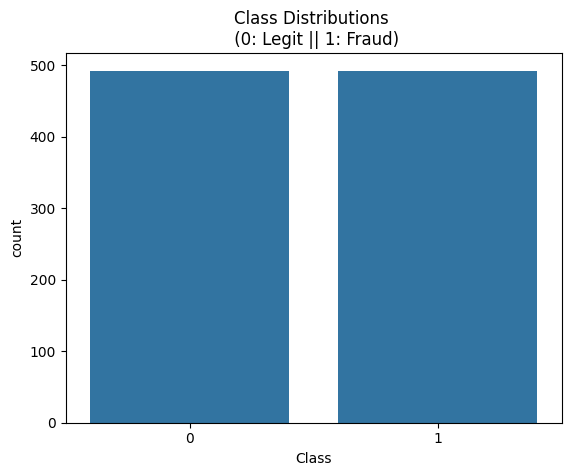

In [29]:
sns.countplot(x='Class', data=new_df)
plt.title('Class Distributions \n (0: Legit || 1: Fraud)')
plt.show()

## Anamoly Detection

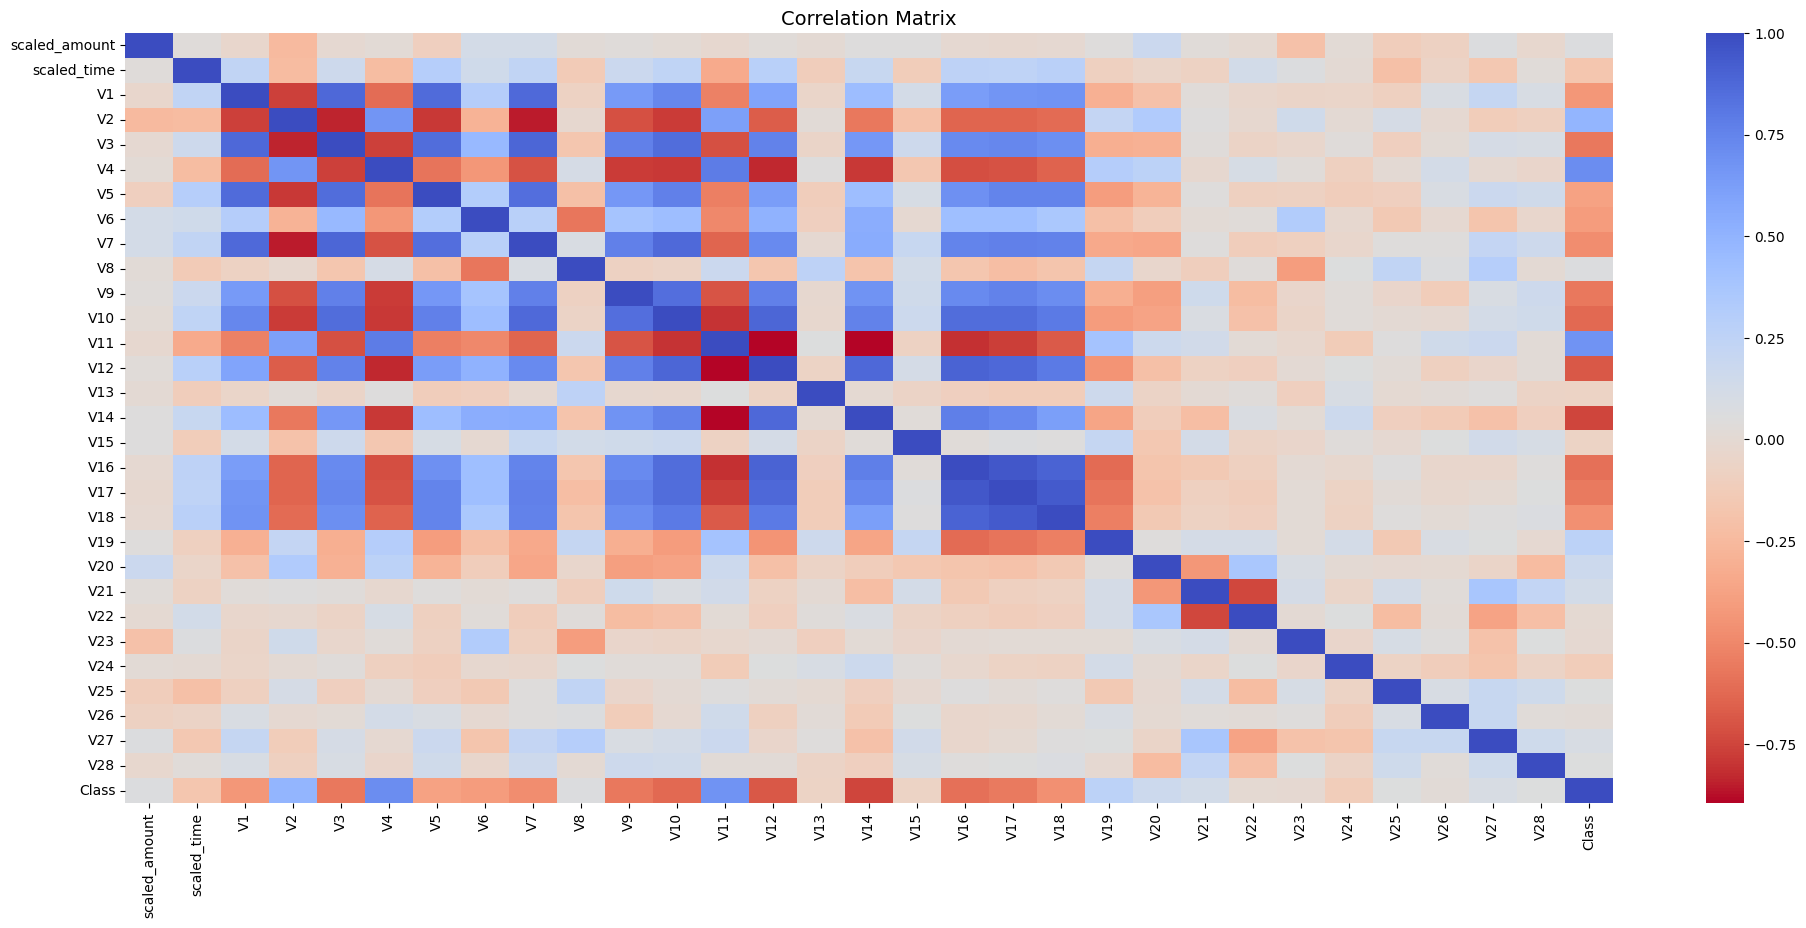

In [31]:
plt.figure(figsize=(24, 10))
new_df_corr = new_df.corr()
sns.heatmap(new_df_corr, cmap='coolwarm_r', annot_kws={'size': 20})
plt.title("Correlation Matrix", fontsize=14)
plt.show()

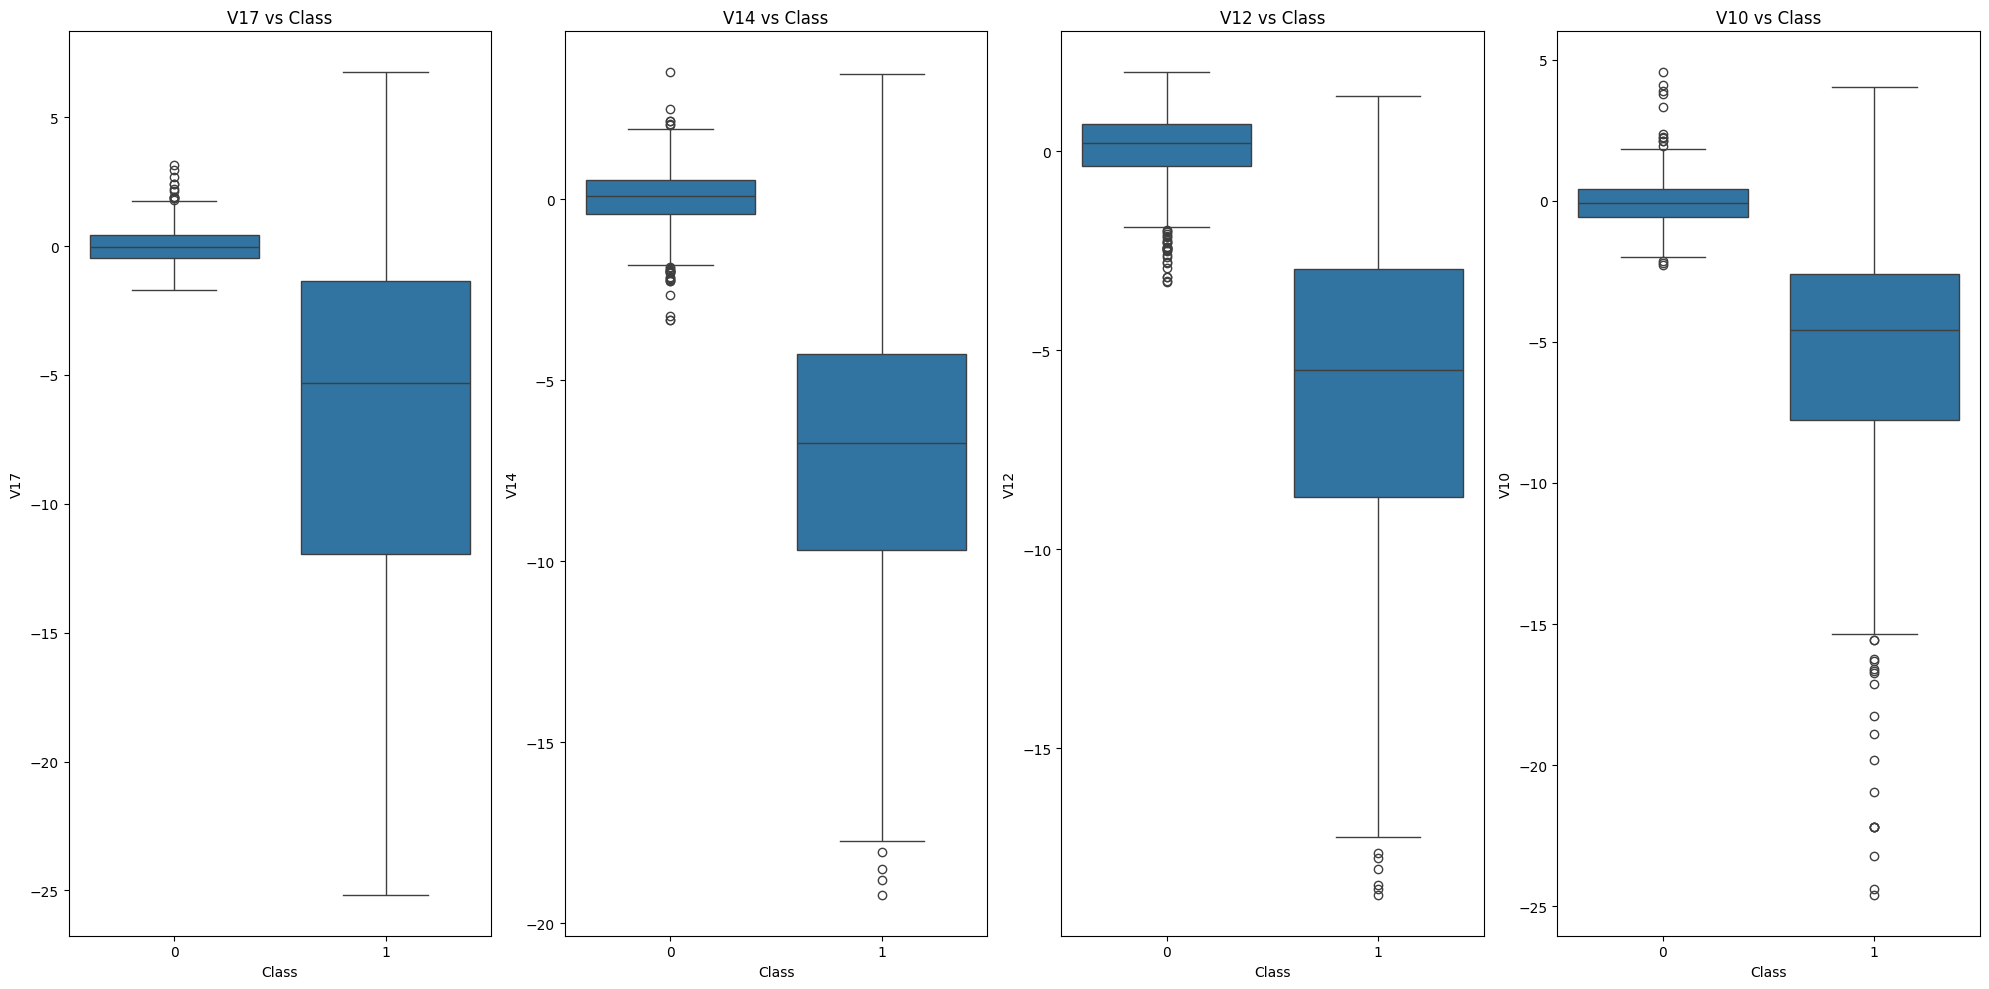

In [33]:
plt.figure(figsize=(20, 10))

plt.subplot(1, 4, 1)
sns.boxplot(x="Class", y="V17", data=new_df)
plt.title("V17 vs Class")

plt.subplot(1, 4, 2)
sns.boxplot(x="Class", y="V14", data=new_df)
plt.title("V14 vs Class")

plt.subplot(1, 4, 3)
sns.boxplot(x="Class", y="V12", data=new_df)
plt.title("V12 vs Class")

plt.subplot(1, 4, 4)
sns.boxplot(x="Class", y="V10", data=new_df)
plt.title("V10 vs Class")

plt.tight_layout()
plt.show()

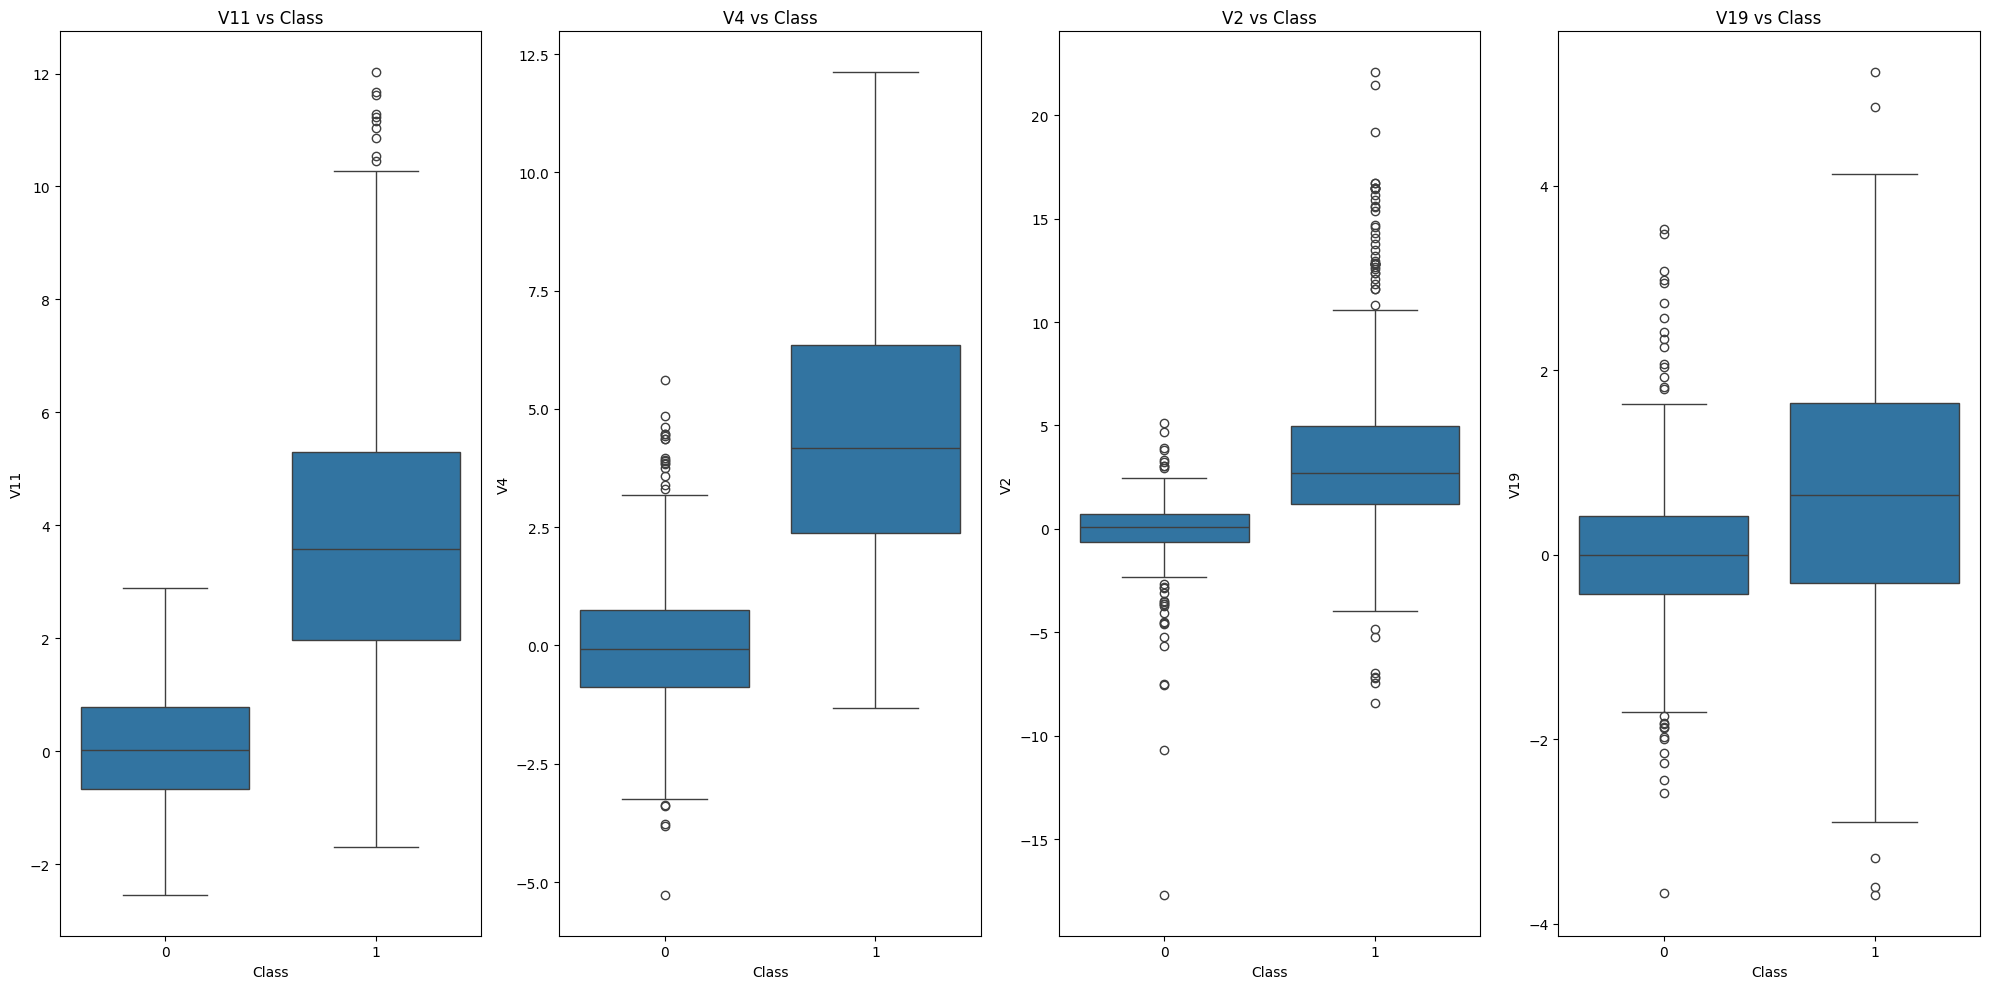

In [34]:
plt.figure(figsize=(20, 10))

plt.subplot(1, 4, 1)
sns.boxplot(x="Class", y="V11", data=new_df)
plt.title("V11 vs Class")

plt.subplot(1, 4, 2)
sns.boxplot(x="Class", y="V4", data=new_df)
plt.title("V4 vs Class")

plt.subplot(1, 4, 3)
sns.boxplot(x="Class", y="V2", data=new_df)
plt.title("V2 vs Class")

plt.subplot(1, 4, 4)
sns.boxplot(x="Class", y="V19", data=new_df)
plt.title("V19 vs Class")

plt.tight_layout()
plt.show()

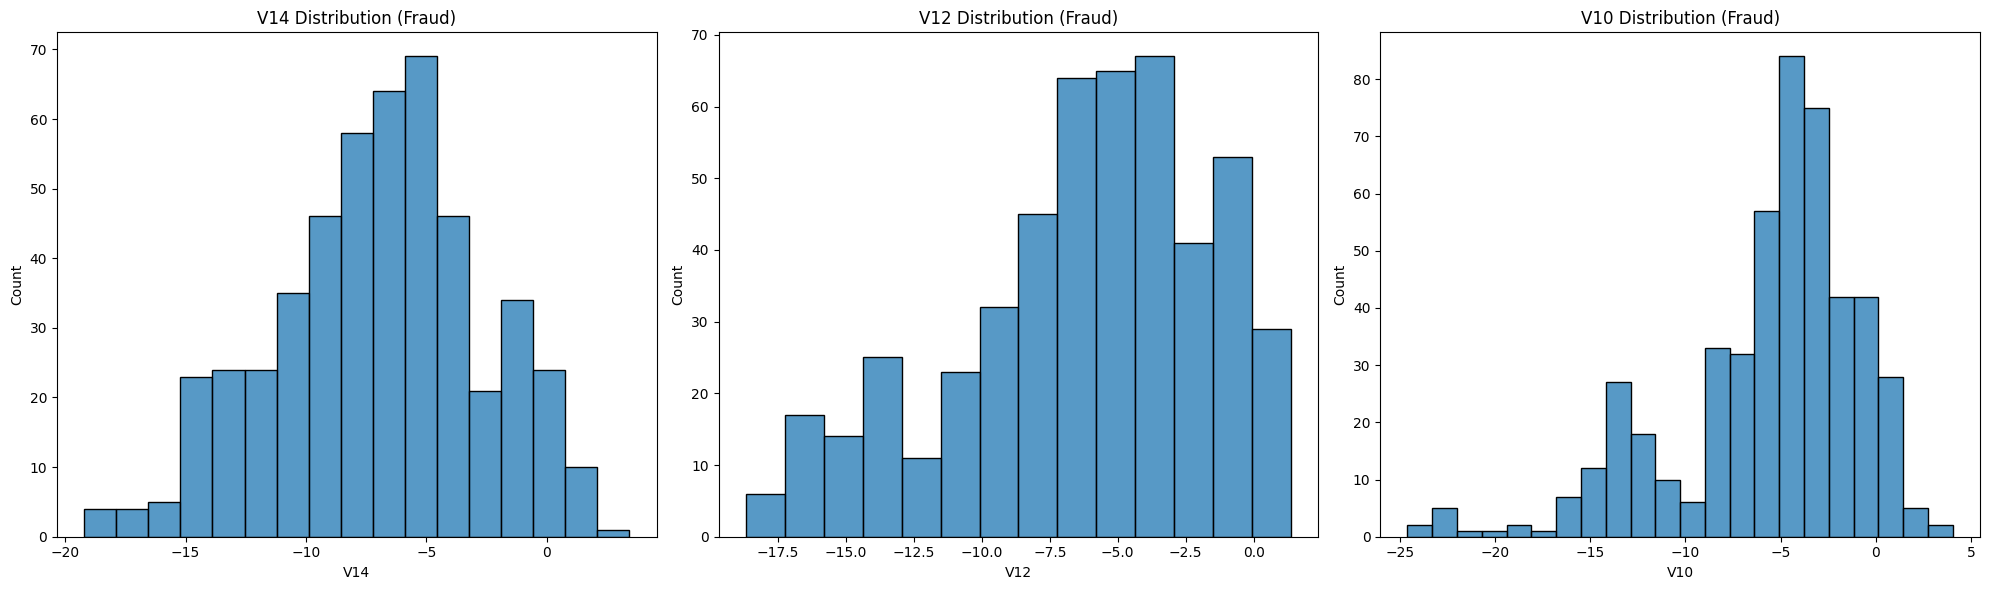

In [38]:
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
fraud_v14 = new_df[new_df['Class'] == 1]['V14']
sns.histplot(fraud_v14)
plt.title('V14 Distribution (Fraud)')

plt.subplot(1, 3, 2)
fraud_v12 = new_df[new_df['Class'] == 1]['V12']
sns.histplot(fraud_v12)
plt.title('V12 Distribution (Fraud)')

plt.subplot(1, 3, 3)
fraud_v10 = new_df[new_df['Class'] == 1]['V10']
sns.histplot(fraud_v10)
plt.title('V10 Distribution (Fraud)')

plt.tight_layout()
plt.show()

In [46]:
#remove outliers from v14
v14_fraud = new_df[new_df["Class"] == 1]["V14"].values
q25, q75 = np.percentile(v14_fraud, 25), np.percentile(v14_fraud, 75)
v14_iqr = q75 - q25
v14_cut_off = v14_iqr * 1.5
v14_lower, v14_upper = q25 - v14_cut_off, q75 + v14_cut_off

print("v14:")
print(f"Q1: {q25}, Q3: {q75}")
print(f"IQR: {v14_iqr}")
print(f"Cutoff: {v14_cut_off}")
print(f"Lower Bound: {v14_lower}")
print(f"Upper Bound: {v14_upper}")

outliers = [x for x in v14_fraud if x < v14_lower or x > v14_upper]
print(f"Outliers Count: {len(outliers)}")
print(f"Outliers: {outliers}")

new_df = new_df[~((new_df["V14"] < v14_lower) | (new_df["V14"] > v14_upper))]

print("\n")

#remove outliers from v12
v12_fraud = new_df[new_df["Class"] == 1]["V12"].values
q25, q75 = np.percentile(v12_fraud, 25), np.percentile(v12_fraud, 75)
v12_iqr = q75 - q25
v12_cut_off = v12_iqr * 1.5
v12_lower, v12_upper = q25 - v12_cut_off, q75 + v12_cut_off

print("v12:")
print(f"Lower Bound: {v12_lower}")
print(f"Upper Bound: {v12_upper}")

outliers = [x for x in v12_fraud if x < v12_lower or x > v12_upper]
print(f"Outliers: {outliers}")
print(f"Outliers Count: {len(outliers)}")

new_df = new_df[~((new_df["V12"] < v12_lower) | (new_df["V12"] > v12_upper))]

print(f"Remaining rows: {len(new_df)}")
print("\n")

#remove outliers from v10
v10_fraud = new_df[new_df["Class"] == 1]["V10"].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
v10_iqr = q75 - q25
v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off
print("v10:")
print(f"Lower Bound: {v10_lower}")
print(f"Upper Bound: {v10_upper}")

outliers = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
print(f"Outliers: {outliers}")
print(f"Outliers Count: {len(outliers)}")

new_df = new_df[~((new_df["V10"] < v10_lower) | (new_df["V10"] > v10_upper))]

print(f"Remaining rows: {len(new_df)}")


v14:
Q1: -8.50012290445807, Q3: -3.9870205315091303
IQR: 4.51310237294894
Cutoff: 6.769653559423411
Lower Bound: -15.269776463881481
Upper Bound: 2.7826330279142804
Outliers Count: 0
Outliers: []


v12:
Lower Bound: -13.378044435013747
Upper Bound: 3.9494393633877123
Outliers: []
Outliers Count: 0
Remaining rows: 889


v10:
Lower Bound: -10.784722569445773
Upper Bound: 3.0245763940529278
Outliers: []
Outliers Count: 0
Remaining rows: 889


## Dimensionality reduction and clustering

In [48]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD


X = new_df.drop('Class', axis=1)
y = new_df['Class']

X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X)

X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X)

X_reduced_svd = TruncatedSVD(n_components=2, random_state=42).fit_transform(X)

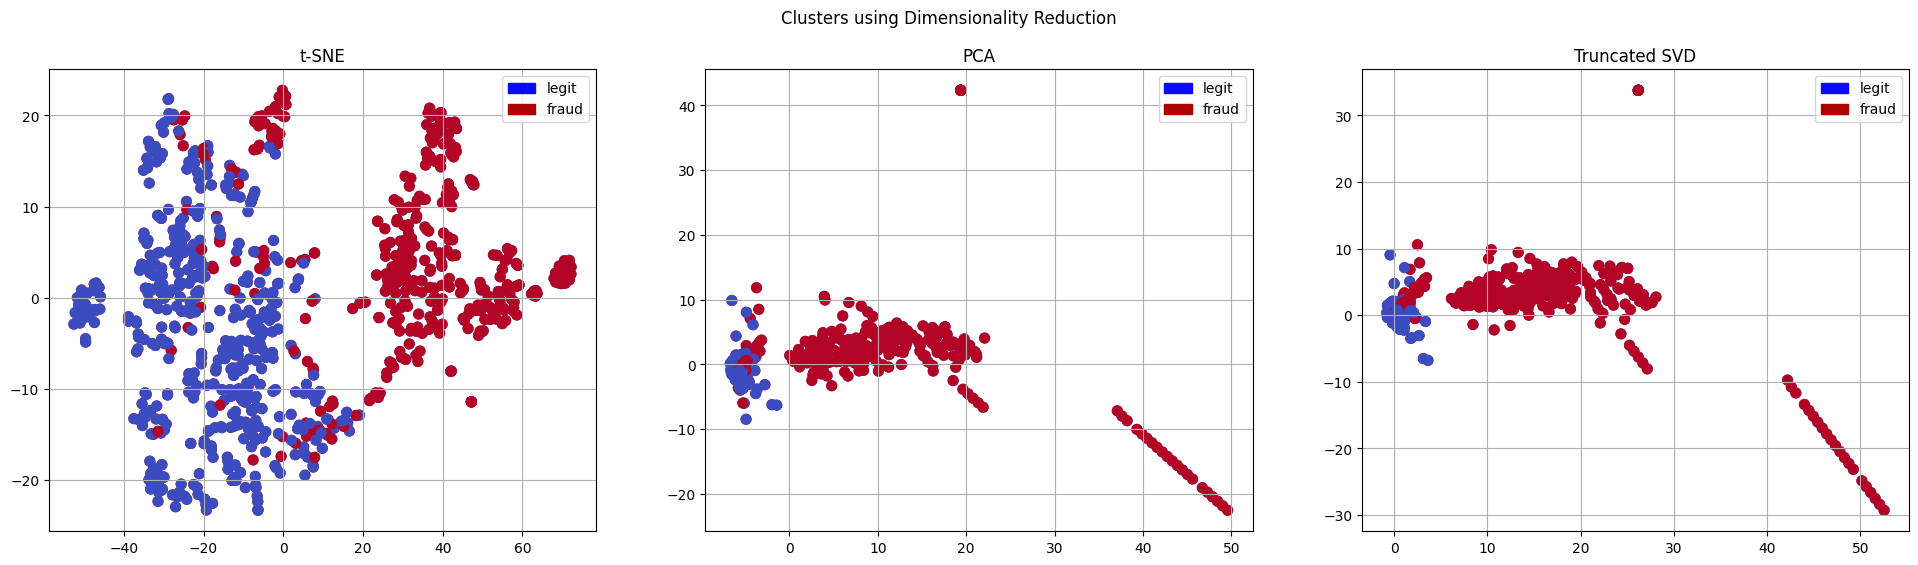

In [53]:
import matplotlib.patches as mpatches

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
f.suptitle('Clusters using Dimensionality Reduction')


blue_patch = mpatches.Patch(color='#0A0AFF', label='legit')
red_patch = mpatches.Patch(color='#AF0000', label='fraud')


#t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='legit', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='faud', linewidths=2)
ax1.set_title('t-SNE')

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])


#PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='legit', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='fraud', linewidths=2)
ax2.set_title('PCA')

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='legit', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='fraud', linewidths=2)
ax3.set_title('Truncated SVD')

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()

## Training

In [54]:
X = new_df.drop('Class', axis=1)
y = new_df['Class']

In [68]:
num_legit = new_df['Class'].value_counts()[0]
num_fraud = new_df['Class'].value_counts()[1]

print("legits:", num_legit)
print("fraud:", num_fraud)

legits: 486
fraud: 403


In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [57]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
log_reg = LogisticRegression()
rf_clf = RandomForestClassifier()

In [59]:
#logistic regression
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

In [60]:
#randomforest
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95        98
           1       0.94      0.95      0.94        80

    accuracy                           0.95       178
   macro avg       0.95      0.95      0.95       178
weighted avg       0.95      0.95      0.95       178



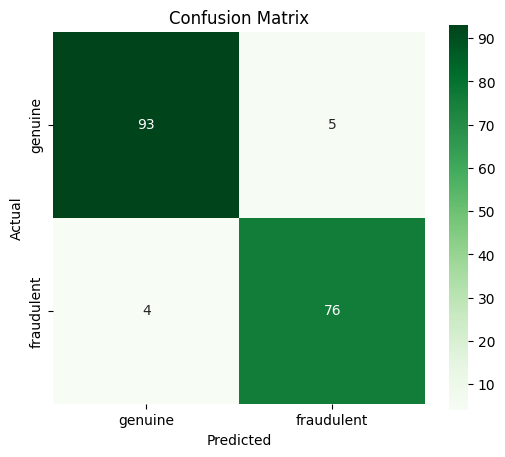

In [66]:
from sklearn.metrics import classification_report, confusion_matrix

print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_log))

cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens', square=True,
            xticklabels=['genuine', 'fraudulent'],
            yticklabels=['genuine', 'fraudulent'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95        98
           1       0.95      0.94      0.94        80

    accuracy                           0.95       178
   macro avg       0.95      0.95      0.95       178
weighted avg       0.95      0.95      0.95       178



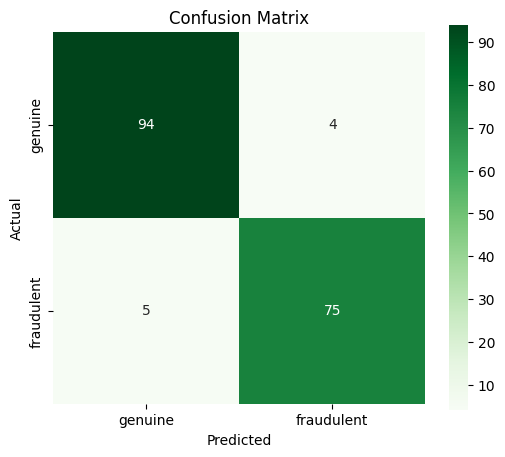

In [67]:
from sklearn.metrics import classification_report, confusion_matrix

print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))

cm_log = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Greens', square=True,
            xticklabels=['genuine', 'fraudulent'],
            yticklabels=['genuine', 'fraudulent'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()